In [ ]:

# # Notebook 01 — Channel Visualization
#
# **Project:** Hierarchical DRL for Subarray & Beam Selection in Near-Field XL-MIMO
#
# This notebook visualizes the near-field channel model from `src/channel/`.
# It produces 7 figures for the report:
#
# 1. Channel magnitude across antennas
# 2. Phase progression (near-field vs far-field)
# 3. Near-field vs far-field channel patterns
# 4. Fraunhofer boundary illustration
# 5. Path loss vs distance
# 6. Regime classification map
# 7. Multi-user channel overview
#
# **How to run:** Open this file in VS Code. Click "Run Cell" above each
# `# %%` block. Plots render inline. All figures are also saved to
# `notebooks/figures/`.

In [ ]:
# %% Cell 1 (minimal fix)
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PROJECT_ROOT = r"C:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys"
FIG_DIR = os.path.join(PROJECT_ROOT, "notebooks", "figures")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.makedirs(FIG_DIR, exist_ok=True)

from src.channel.near_field import NearFieldChannel, ChannelParameters
from src.channel.channel_generator import ChannelGenerator, ChannelGeneratorConfig

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Imports OK")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Figures saved: {FIG_DIR}")

Imports OK
Project root:  C:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys
Figures saved: C:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures


In [ ]:
# %% Cell 2: Create channel model
params = ChannelParameters(
    num_antennas=64,
    antenna_spacing=0.5,
    array_type="uniform_linear",
    carrier_frequency=28e9,
    path_loss_exponent=2.0,
)
channel = NearFieldChannel(params)

# Cache derived params as non-Optional floats (Pylance-friendly)
FRAUNHOFER: float = float(channel.compute_fraunhofer_distance())
WAVELENGTH: float = float(
    params.wavelength if params.wavelength is not None
    else 3e8 / params.carrier_frequency
)
ANTENNA_SPACING_M: float = params.antenna_spacing * WAVELENGTH

print(f"Array: {params.num_antennas} antennas, {params.array_type}")
print(f"Carrier: {params.carrier_frequency/1e9:.1f} GHz")
print(f"Wavelength: {WAVELENGTH*1000:.2f} mm")
print(f"Fraunhofer distance: {FRAUNHOFER:.2f} m")
print(f"Antenna spacing: {ANTENNA_SPACING_M*1000:.2f} mm")
print(f"Array axis: Y (positions have y-coords only)")

Array: 64 antennas, uniform_linear
Carrier: 28.0 GHz
Wavelength: 10.71 mm
Fraunhofer distance: 21.94 m
Antenna spacing: 5.36 mm
Array axis: Y (positions have y-coords only)


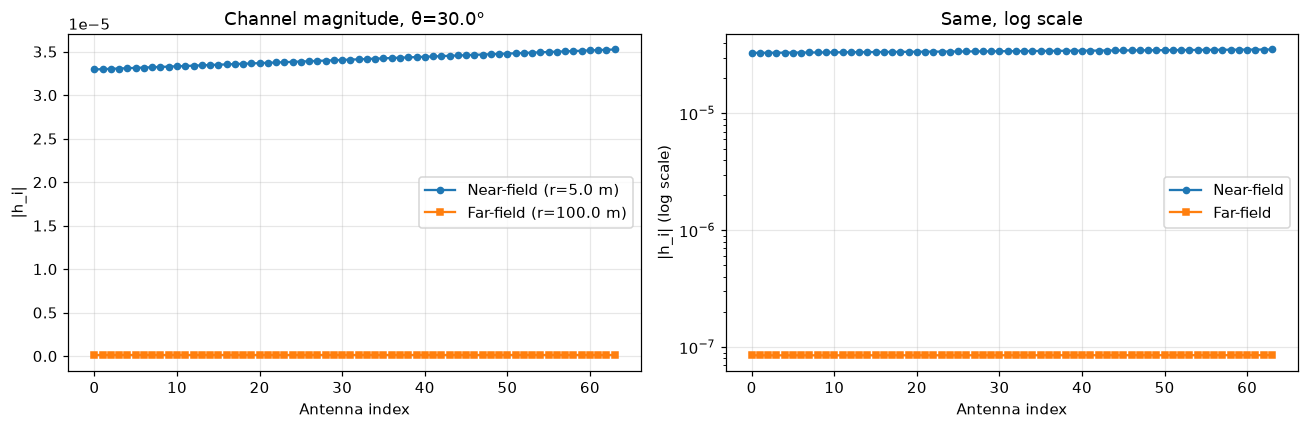

In [ ]:
# %% Cell 3: FIGURE 1 — Channel magnitude across antennas
angle_deg = 30.0
r_near = 5.0
r_far = 100.0

angle_rad = np.radians(angle_deg)
users = np.array([
    [r_near * np.cos(angle_rad), r_near * np.sin(angle_rad), 0.0],
    [r_far * np.cos(angle_rad), r_far * np.sin(angle_rad), 0.0],
])

H = channel.compute_channel(users, include_path_loss=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.abs(H[0]), "o-", label=f"Near-field (r={r_near} m)", markersize=4)
axes[0].plot(np.abs(H[1]), "s-", label=f"Far-field (r={r_far} m)", markersize=4)
axes[0].set_xlabel("Antenna index")
axes[0].set_ylabel("|h_i|")
axes[0].set_title(f"Channel magnitude, θ={angle_deg}°")
axes[0].legend()

axes[1].semilogy(np.abs(H[0]), "o-", label="Near-field", markersize=4)
axes[1].semilogy(np.abs(H[1]), "s-", label="Far-field", markersize=4)
axes[1].set_xlabel("Antenna index")
axes[1].set_ylabel("|h_i| (log scale)")
axes[1].set_title("Same, log scale")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_channel_magnitude.png"))
plt.show()

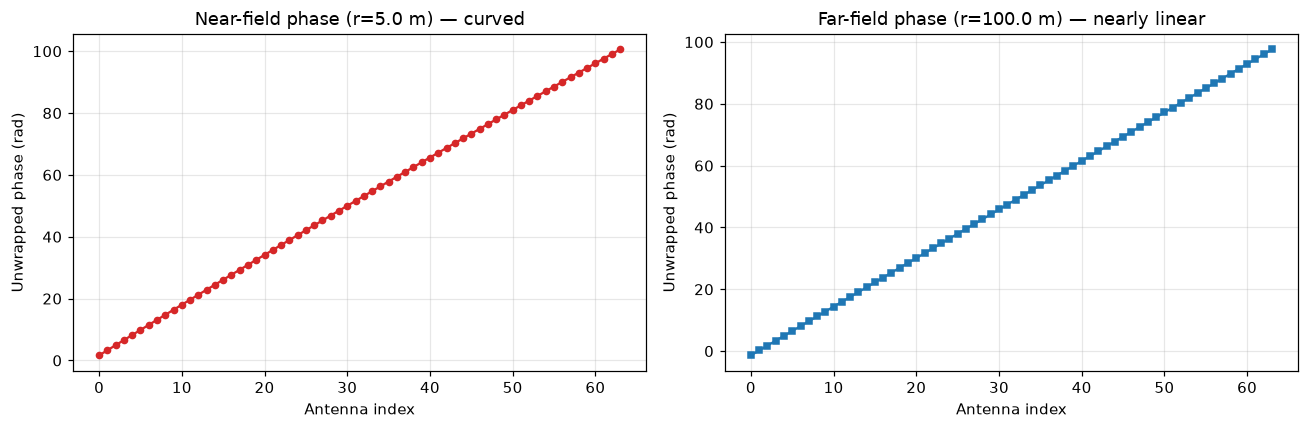

In [ ]:
# %% Cell 4: FIGURE 2 — Phase progression
antennas = np.arange(params.num_antennas)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

H_nf = channel.compute_channel(
    np.array([[r_near * np.cos(angle_rad), r_near * np.sin(angle_rad), 0.0]]),
    include_path_loss=False,
)
phase_nf = np.unwrap(np.angle(H_nf[0]))
axes[0].plot(antennas, phase_nf, "o-", color="tab:red", markersize=4)
axes[0].set_xlabel("Antenna index")
axes[0].set_ylabel("Unwrapped phase (rad)")
axes[0].set_title(f"Near-field phase (r={r_near} m) — curved")
axes[0].grid(True, alpha=0.3)

H_ff = channel.compute_channel(
    np.array([[r_far * np.cos(angle_rad), r_far * np.sin(angle_rad), 0.0]]),
    include_path_loss=False,
)
phase_ff = np.unwrap(np.angle(H_ff[0]))
axes[1].plot(antennas, phase_ff, "s-", color="tab:blue", markersize=4)
axes[1].set_xlabel("Antenna index")
axes[1].set_ylabel("Unwrapped phase (rad)")
axes[1].set_title(f"Far-field phase (r={r_far} m) — nearly linear")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_phase_progression.png"))
plt.show()

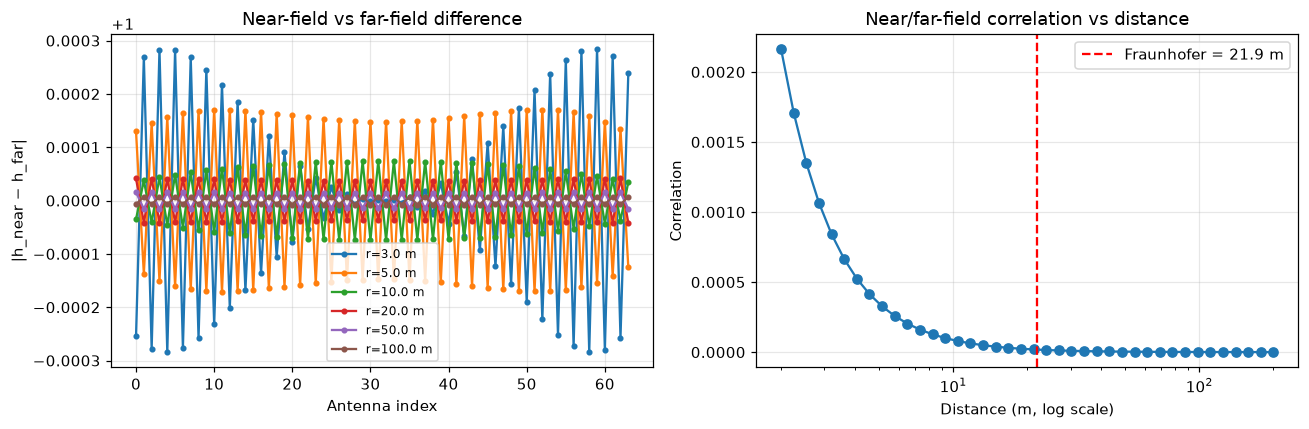

In [ ]:
# %% Cell 5: FIGURE 3 — Near-field vs far-field difference
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for r in [3.0, 5.0, 10.0, 20.0, 50.0, 100.0]:
    user = np.array([[r * np.cos(angle_rad), r * np.sin(angle_rad), 0.0]])
    H_nf = channel.compute_channel(user, include_path_loss=False)
    H_ff = channel.compute_far_field_channel(user)
    diff = np.abs(H_nf[0] - H_ff[0])
    axes[0].plot(diff, "o-", label=f"r={r} m", markersize=3)

axes[0].set_xlabel("Antenna index")
axes[0].set_ylabel("|h_near − h_far|")
axes[0].set_title("Near-field vs far-field difference")
axes[0].legend(fontsize=8)

distances = np.logspace(np.log10(2.0), np.log10(200.0), 40)
corrs = []
for r in distances:
    user = np.array([[r * np.cos(angle_rad), r * np.sin(angle_rad), 0.0]])
    H_nf = channel.compute_channel(user, include_path_loss=False)
    H_ff = channel.compute_far_field_channel(user)
    c = np.abs(np.vdot(H_nf[0], H_ff[0])) / (
        np.linalg.norm(H_nf[0]) * np.linalg.norm(H_ff[0])
    )
    corrs.append(c)

axes[1].semilogx(distances, corrs, "o-")
axes[1].axvline(FRAUNHOFER, color="red", linestyle="--",
                label=f"Fraunhofer = {FRAUNHOFER:.1f} m")
axes[1].set_xlabel("Distance (m, log scale)")
axes[1].set_ylabel("Correlation")
axes[1].set_title("Near/far-field correlation vs distance")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_near_vs_far_field.png"))
plt.show()

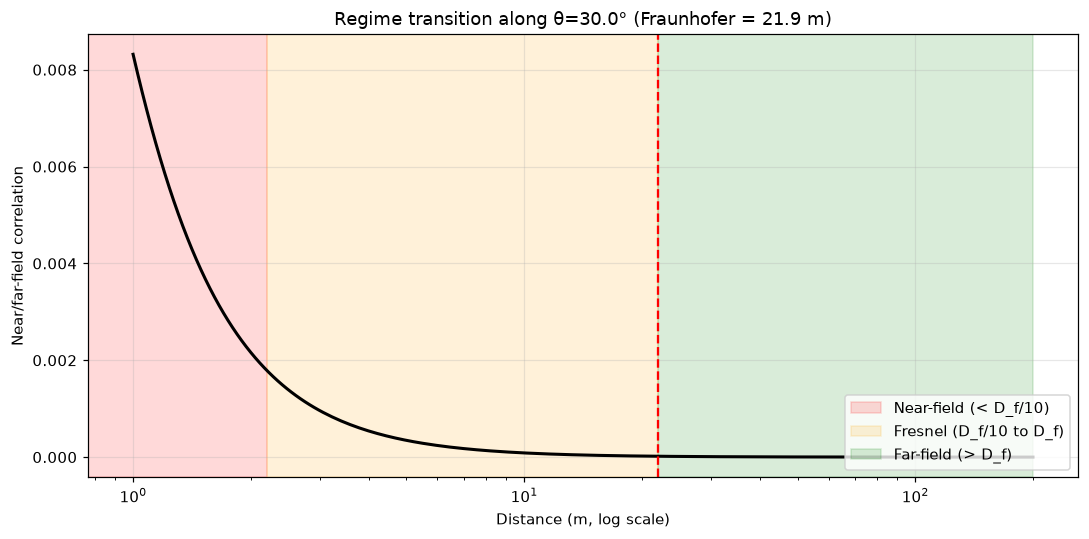

In [ ]:
# %% Cell 6: FIGURE 4 — Fraunhofer boundary illustration
distances = np.logspace(np.log10(1.0), np.log10(200.0), 200)
corrs = []
for r in distances:
    user = np.array([[r * np.cos(angle_rad), r * np.sin(angle_rad), 0.0]])
    H_nf = channel.compute_channel(user, include_path_loss=False)
    H_ff = channel.compute_far_field_channel(user)
    c = np.abs(np.vdot(H_nf[0], H_ff[0])) / (
        np.linalg.norm(H_nf[0]) * np.linalg.norm(H_ff[0])
    )
    corrs.append(c)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(distances, corrs, "-", color="black", linewidth=2)

ax.axvspan(0, FRAUNHOFER / 10, color="red", alpha=0.15, label="Near-field (< D_f/10)")
ax.axvspan(FRAUNHOFER / 10, FRAUNHOFER, color="orange", alpha=0.15,
           label="Fresnel (D_f/10 to D_f)")
ax.axvspan(FRAUNHOFER, 200, color="green", alpha=0.15, label="Far-field (> D_f)")
ax.axvline(FRAUNHOFER, color="red", linestyle="--", linewidth=1.5)

ax.set_xlabel("Distance (m, log scale)")
ax.set_ylabel("Near/far-field correlation")
ax.set_title(f"Regime transition along θ={angle_deg}° (Fraunhofer = {FRAUNHOFER:.1f} m)")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_fraunhofer_boundary.png"))
plt.show()

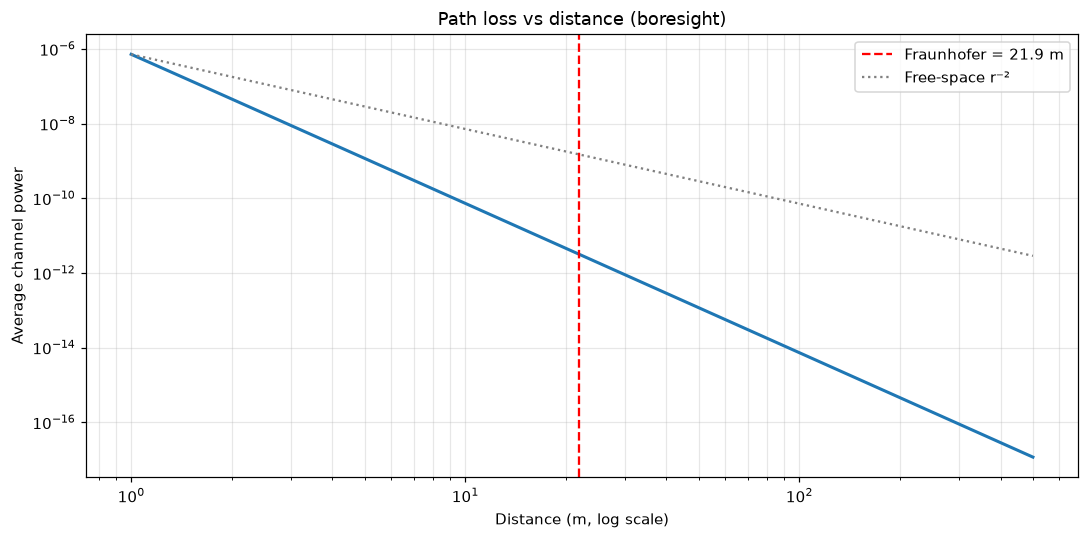

In [ ]:
# %% Cell 7: FIGURE 5 — Path loss vs distance
distances = np.logspace(np.log10(1.0), np.log10(500.0), 200)

powers = []
for r in distances:
    user = np.array([[r, 0.0, 0.0]])
    H = channel.compute_channel(user, include_path_loss=True)
    powers.append(np.mean(np.abs(H[0]) ** 2))
powers = np.array(powers)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(distances, powers, "-", linewidth=2)
ax.axvline(FRAUNHOFER, color="red", linestyle="--",
           label=f"Fraunhofer = {FRAUNHOFER:.1f} m")

# Free-space reference
ref = powers[0] * (distances[0] / distances) ** 2
ax.loglog(distances, ref, ":", color="gray", label="Free-space r⁻²")

ax.set_xlabel("Distance (m, log scale)")
ax.set_ylabel("Average channel power")
ax.set_title("Path loss vs distance (boresight)")
ax.legend()
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_path_loss.png"))
plt.show()

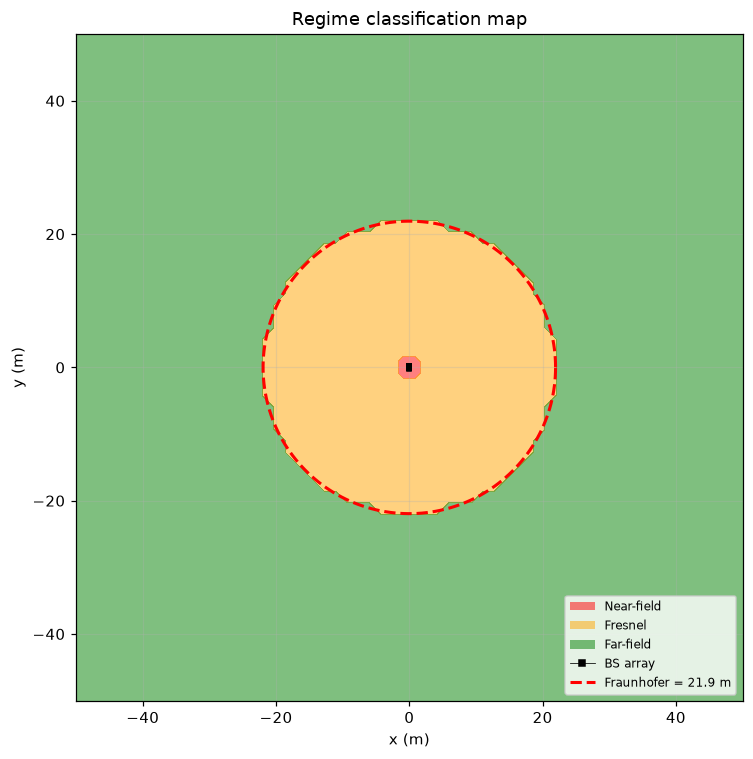

In [ ]:
# %% Cell 8: FIGURE 6 — Regime classification map
x_grid = np.linspace(-50, 50, 60)
y_grid = np.linspace(-50, 50, 60)
XX, YY = np.meshgrid(x_grid, y_grid)
RR = np.sqrt(XX**2 + YY**2)

regime_map = np.zeros_like(RR, dtype=int)
regime_map[RR < FRAUNHOFER / 10] = 0
regime_map[(RR >= FRAUNHOFER / 10) & (RR < FRAUNHOFER)] = 1
regime_map[RR >= FRAUNHOFER] = 2

fig, ax = plt.subplots(figsize=(8, 7))
ax.contourf(XX, YY, regime_map, levels=[-0.5, 0.5, 1.5, 2.5],
            colors=["red", "orange", "green"], alpha=0.5)

# BS array (y-axis)
antennas_x = np.zeros(params.num_antennas)
antennas_y = channel.antenna_positions[:, 1]
ax.plot(antennas_x, antennas_y, "ks-", markersize=2, linewidth=0.5)

# Fraunhofer circle
theta_circle = np.linspace(0, 2 * np.pi, 200)
ax.plot(FRAUNHOFER * np.cos(theta_circle), FRAUNHOFER * np.sin(theta_circle),
        "r--", linewidth=2)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Regime classification map")
ax.set_aspect("equal")
ax.set_xlim(-50, 50)
ax.set_ylim(-50, 50)

legend_elements = [
    Patch(facecolor="red", alpha=0.5, label="Near-field"),
    Patch(facecolor="orange", alpha=0.5, label="Fresnel"),
    Patch(facecolor="green", alpha=0.5, label="Far-field"),
    Line2D([0], [0], color="k", marker="s", linestyle="-",
           markersize=4, linewidth=0.5, label="BS array"),
    Line2D([0], [0], color="r", linestyle="--", linewidth=2,
           label=f"Fraunhofer = {FRAUNHOFER:.1f} m"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_regime_map.png"))
plt.show()

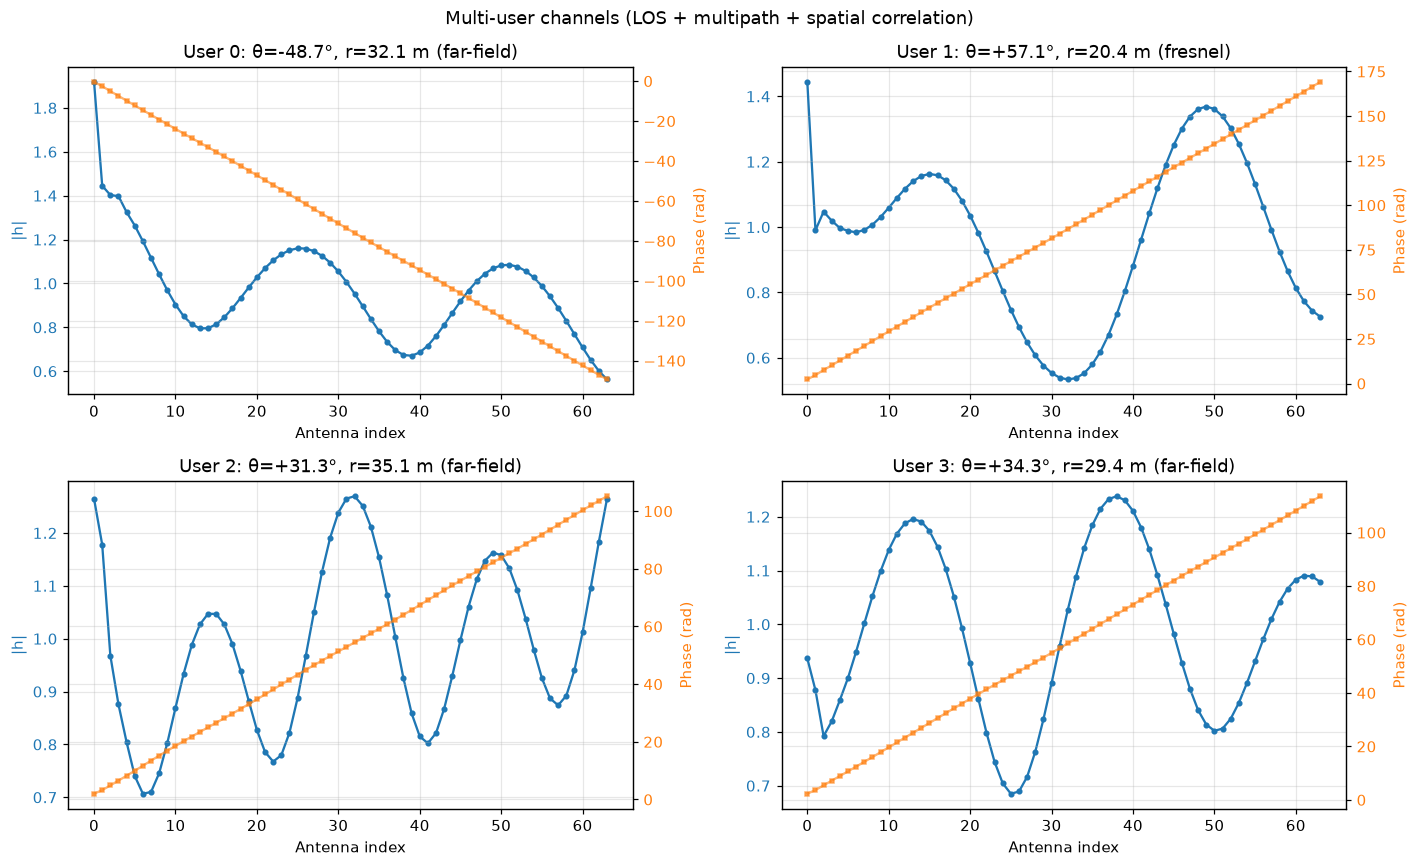

In [ ]:
# %% Cell 9: FIGURE 7 — Multi-user channel overview
gen_config = ChannelGeneratorConfig(
    num_users=4,
    num_antennas=64,
    num_multipath=3,
    spatial_correlation=True,
    correlation_factor=0.3,
    normalize_channels=True,
    user_distance_range=(5.0, 40.0),
    user_angle_range=(-60.0, 60.0),
    seed=42,
)
generator = ChannelGenerator(gen_config)
H_multi = generator.generate_channel_matrix()

# Cache user positions as non-Optional
positions = generator._user_positions
if positions is None:
    positions = generator.generate_user_positions()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for u in range(4):
    ax = axes[u // 2, u % 2]
    mag = np.abs(H_multi[u])
    phase = np.unwrap(np.angle(H_multi[u]))

    ax2 = ax.twinx()
    ax.plot(mag, "o-", color="tab:blue", markersize=3, label="|h|")
    ax2.plot(phase, "s-", color="tab:orange", markersize=3, alpha=0.6,
             label="phase")

    ax.set_xlabel("Antenna index")
    ax.set_ylabel("|h|", color="tab:blue")
    ax2.set_ylabel("Phase (rad)", color="tab:orange")
    ax.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    pos = positions[u]
    d = float(np.linalg.norm(pos))
    theta = float(np.degrees(np.arctan2(pos[1], pos[0])))
    regime = channel.get_regime(d)
    ax.set_title(f"User {u}: θ={theta:+.1f}°, r={d:.1f} m ({regime})")

plt.suptitle("Multi-user channels (LOS + multipath + spatial correlation)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_multi_user.png"))
plt.show()

In [ ]:
# %% Cell 10: Summary
print("\n" + "=" * 60)
print("Channel Visualization — Summary")
print("=" * 60)
print(f"\nFigures saved to: {FIG_DIR}")
for i, name in enumerate([
    "01_channel_magnitude.png",
    "02_phase_progression.png",
    "03_near_vs_far_field.png",
    "04_fraunhofer_boundary.png",
    "05_path_loss.png",
    "06_regime_map.png",
    "07_multi_user.png",
], 1):
    full_path = os.path.join(FIG_DIR, name)
    exists = os.path.exists(full_path)
    print(f"  [{i}] {name:35s} {'✓' if exists else '✗ MISSING'}")

print(f"\nKey observations:")
print(f"  • Fraunhofer distance: {FRAUNHOFER:.2f} m")
print(f"  • Near-field region: r < {FRAUNHOFER/10:.2f} m")
print(f"  • Fresnel region: {FRAUNHOFER/10:.2f} m < r < {FRAUNHOFER:.2f} m")
print(f"  • Far-field region: r > {FRAUNHOFER:.2f} m")
print(f"\nNotebook 01 complete.")


Channel Visualization — Summary

Figures saved to: C:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures
  [1] 01_channel_magnitude.png            ✓
  [2] 02_phase_progression.png            ✓
  [3] 03_near_vs_far_field.png            ✓
  [4] 04_fraunhofer_boundary.png          ✓
  [5] 05_path_loss.png                    ✓
  [6] 06_regime_map.png                   ✓
  [7] 07_multi_user.png                   ✓

Key observations:
  • Fraunhofer distance: 21.94 m
  • Near-field region: r < 2.19 m
  • Fresnel region: 2.19 m < r < 21.94 m
  • Far-field region: r > 21.94 m

Notebook 01 complete.
